## Import the modules you need (this does not need to change)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import importlib
import glob
import os
import matplotlib.cm as cm
import math as math
from scipy import signal
from scipy.fftpack import fft, ifft
from scipy.signal import savgol_filter
from collections import Counter
from ipywidgets import interactive
import _pickle as pickle

In [2]:
import time

In [3]:

import matplotlib 
from matplotlib.colors import ListedColormap, LinearSegmentedColormap

## All the functions for plotting are in here

In [4]:
import LDQM_dataplot

importlib.reload(LDQM_dataplot)

<module 'LDQM_dataplot' from 'C:\\jdiez_local\\Code\\LDQM_dataplot.py'>

In [85]:
import capacitor_simulation

importlib.reload(capacitor_simulation)

<module 'capacitor_simulation' from 'C:\\jdiez_local\\Code\\capacitor_simulation.py'>

In [6]:
import basic_plotting

importlib.reload(basic_plotting)


<module 'basic_plotting' from 'C:\\jdiez_local\\Code\\basic_plotting.py'>

In [7]:
import LDQM_dataplot
import homemade_functions 
import capacitor_simulation

savename='C:/Users/jdiez/LDQM/a. Data/Ju1/Fig/'
savecount=1


orig_cmap = matplotlib.cm.RdBu_r
mycolor=LDQM_dataplot.shiftedColorMap(0.5,orig_cmap)

font=16

def update_modules():
    
    importlib.reload(LDQM_dataplot)

    importlib.reload(homemade_functions)
    importlib.reload(capacitor_simulation)

In [89]:
update_modules()

from homemade_functions import runningMeanFast
from homemade_functions import plot_pre,plot_map,plot_line,plot_premap

In [9]:
class Object():
    pass

# We need to create a mesh and give BCs
## Dirichlet BCs give a finite value to the edges while Neumann BCs give the derivative of the potential. 
### irchlet is useful for metal plates, so for example
## for our back gate. For the top gates we will need some other condition for the empty part. So maybe
## the top part has to be a mixed of Dirichlet and Neuman BCs

# JJ architecture: 
## - Vtop= 0, hBN thickneses 
## - Vbot = 0, hBN thickneses
## - Vtop != 0, hBN thicknesses 
## - Vtop != 0, junction size 
## - Vbot=0, junction size


In [10]:
a=4
if a%4==0:
    a=a+1
a

5

In [52]:
# Save is true so the images and the object are saved. Everytime make a new folder for it 
importlib.reload(capacitor_simulation)
save_folder='C:/jdiez_local/LDQM/e. Simulations/'
savename=save_folder+'231123_GoodJJ/'

In [63]:
# General settings 

units=1 # Units of 2.5 Angstrongs, 4 units is 1 nm
ds=1
dsy=1

# Dielectric values. Permittivity of hBn is epsilonr- 3-4
## Same permitivity to both, the difference is in the thickness 
top_epsr=4
print('Epsilon top is '+str(top_epsr))
bot_epsr=4

eps=10E-4 # Convergence threshold

plate_start_x=1

### This size gives a good simulation time and also allows to focus on the central region ignoring the 
###effects for the end of the gates, which gives artifacts due to BCs 

Nx=601*units
if Nx%2==0:
    Nx=Nx+1
Ny=81*units
if Ny%2==0:
    Ny=Ny+1
    
count=0 # This will count to make the total object with all the iterations 
save=False
print('Save value is '+str(save))

### MAKE the dictionary

data_cap_JJ_Ju1={}


Epsilon top is 4
Save value is False


## 1. Vtop = 0, check the homogeneity of the gating at different hBN thickness and cut size

In [93]:
count=0

In [94]:
update_modules()

Save settings is set to False
Over relaxation constant is: 1.8971385788315365
 iterations =133


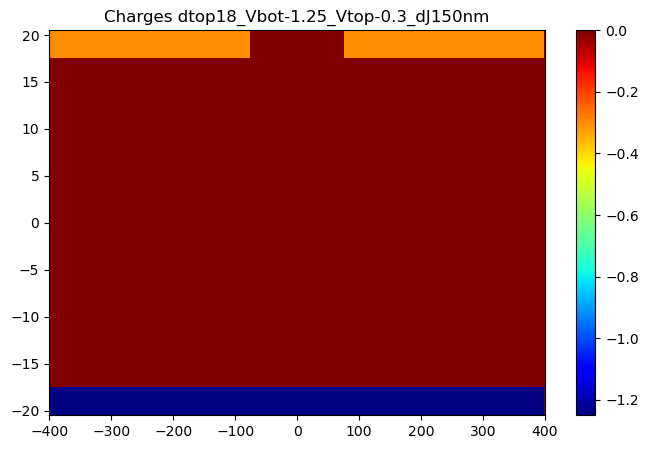

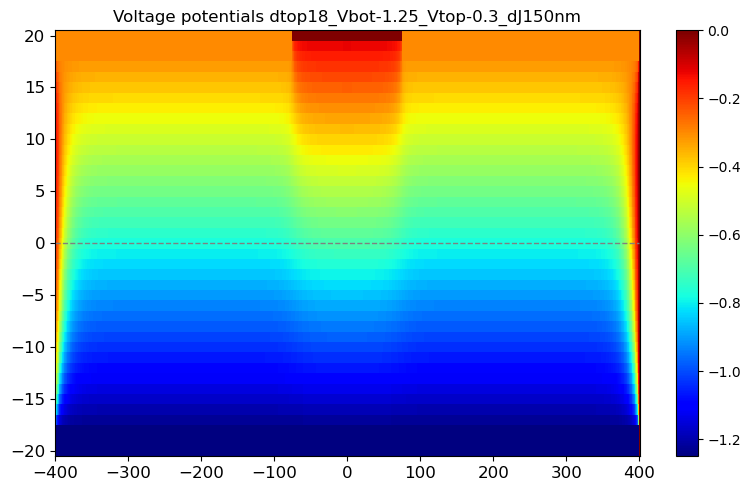

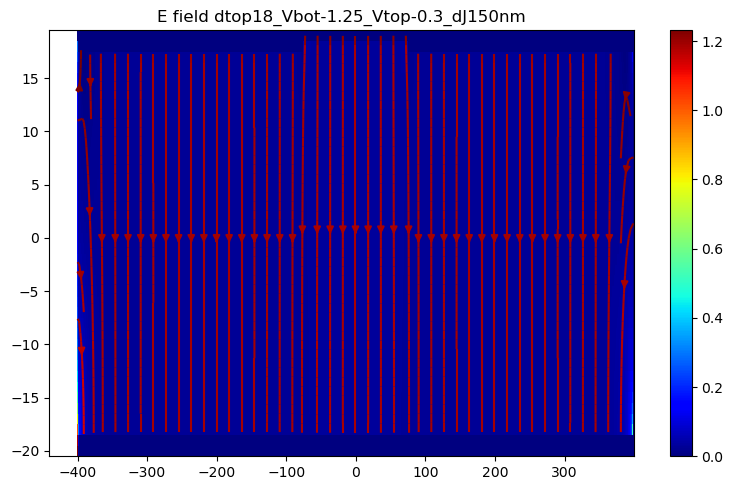

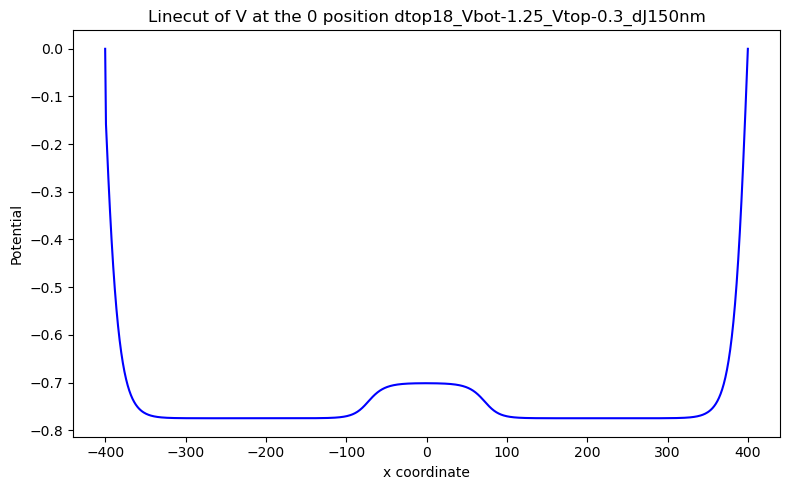

using Dirchlet and realistic size takes 63.73417568206787 seconds ---


In [95]:
### General settings for this iteration### 

### Charges### 
rho_top_left=-0.3
rho_bot=-1.25

### Top half as bottom 14 nm ###
hBN_thickness=int(20*units)  # hbn 14 nm 
bot_to_0=hBN_thickness

## Common names ## 
name2='Ju1 $V_{bot}=$'+str(rho_bot)+'_$V_{top}=$'+str(rho_top_left)

top_hBN=18 ## top hBN thickness
extend_electrodes=1

cut_x=int(75*units) ## junction size
name1='units='+str(units)+'_$d_J$='+str(int(2*cut_x/units))+'nm_'

top_to_0=int(top_hBN*units)
#Ny=bot_to_0+top_to_0+2
#if Ny%2==0:
#    Ny=Ny+1
#bot_plate_y= 0+1
#top_plate_y=Ny-2
    
start_time=time.time()

name3='_$d_{top}$='+str(int(top_to_0/units))+'$d_{bot}$='+str(int(bot_to_0/4))
save_plot_name='dtop'+str(int(top_to_0/units))+'_Vbot'+str(rho_bot)+'_Vtop'+str(rho_top_left)+'_dJ'+str(int(2*cut_x/units))+'nm'
plot_name=name1+name2+name3

data_cap_JJ_Ju1['data'+str(count)]=capacitor_simulation.capacitors_Dirich(Nx,ds,dsy,rho_top_left,rho_bot,
                bot_to_0,top_to_0,bot_epsr,
                top_epsr,plate_start_x,cut_x,eps, plot_names=save_plot_name,save=save,savename=savename,top_size=1,
                bot_size=1, hd=0,save_obj=save,
                mid_split=False,max_iter=1E4)

print("using Dirchlet and realistic size takes %s seconds ---" % (time.time() - start_time))

count=count+1 ## Add the count to keep storing the data 


In [79]:
count

4

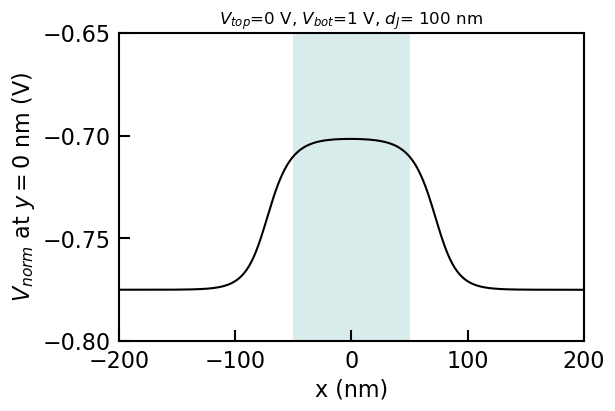

In [84]:
## Units are 2.5 A, so I divide by 4 to get nm

ax=plot_pre(6,4)
zeroline=int(Ny/2)
i=3
ax.plot(data_cap_JJ_Ju1['data'+str(i)].x_real[zeroline],data_cap_JJ_Ju1['data'+str(i)].V[zeroline],'k')
plot_line(ax,xlabel='x (nm)',ylabel='$V_{norm}$ at $y = 0$ nm (V)',legx=0.25,legy=0.5,font_size=16,font_leg=2,leg=False)
#ax.axvline(x=0,linestyle='dashed',color='silver')
ax.axvspan(-50,50,facecolor='teal',alpha=0.15)
#ax.axvspan(-100,-50,facecolor='teal',alpha=0.2)
#ax.axvspan(50,100,facecolor='teal',alpha=0.2)
ax.set_xlim(-200,200)
ax.set_ylim(-0.8,-0.65)
#ax.axhline(y=0,linestyle='dashed',color='silver',linewidth=1)
ax.set_title('$V_{top}$=0 V, $V_{bot}$=1 V, $d_J$= 100 nm')
#ax.legend(loc='upper center', bbox_to_anchor=(0.21, 1.02), shadow=False, ncol=1,fontsize=12,frameon=False)
plt.show()

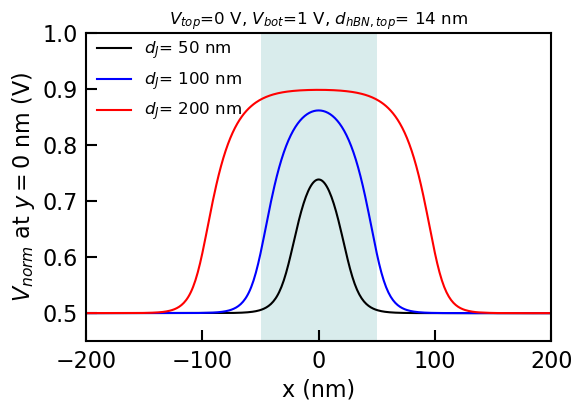

In [392]:
## Units are 2.5 A, so I divide by 4 to get nm

ax=plot_pre(6,4)
zeroline=int(Ny/2)
i=1
ax.plot(data_cap_JJ['data'+str(i)].x_real[zeroline],data_cap_JJ['data'+str(i)].V[zeroline],'k',label='$d_{J}$= 50 nm')
i=4
ax.plot(data_cap_JJ['data'+str(i)].x_real[zeroline],data_cap_JJ['data'+str(i)].V[zeroline],'b',label='$d_{J}$= 100 nm')
i=7
ax.plot(data_cap_JJ['data'+str(i)].x_real[zeroline],data_cap_JJ['data'+str(i)].V[zeroline],'r',label='$d_{J}$= 200 nm')
plot_line(ax,xlabel='x (nm)',ylabel='$V_{norm}$ at $y = 0$ nm (V)',legx=0.25,legy=0.5,font_size=16,font_leg=2,leg=True)
#ax.axvline(x=0,linestyle='dashed',color='silver')
ax.axvspan(-50,50,facecolor='teal',alpha=0.15)
#ax.axvspan(-100,-50,facecolor='teal',alpha=0.2)
#ax.axvspan(50,100,facecolor='teal',alpha=0.2)
ax.set_xlim(-200,200)
ax.set_ylim(0.45,1)
ax.axhline(y=0,linestyle='dashed',color='silver',linewidth=1)
ax.set_title('$V_{top}$=0 V, $V_{bot}$=1 V, $d_{hBN,top}$= 14 nm')
ax.legend(loc='upper center', bbox_to_anchor=(0.18, 1.03), shadow=False, ncol=1,fontsize=12,frameon=False)
plt.show()

In [47]:
bot_epsr

4

Save settings is set to False
Over relaxation constant is: 1.912680152280137
 iterations =174


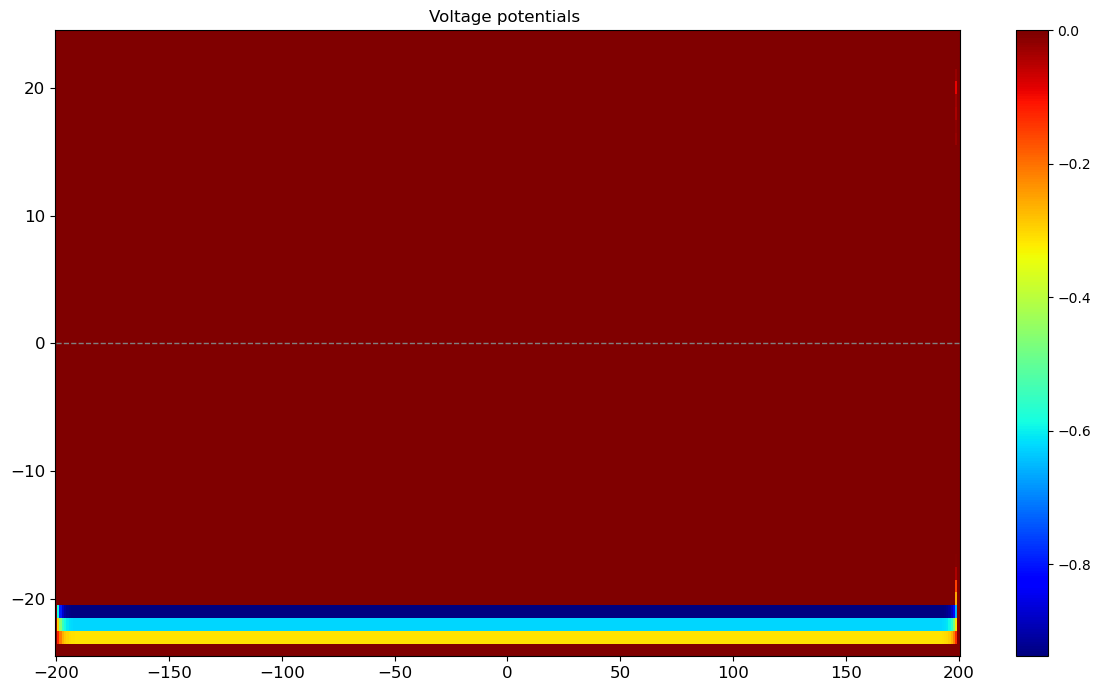

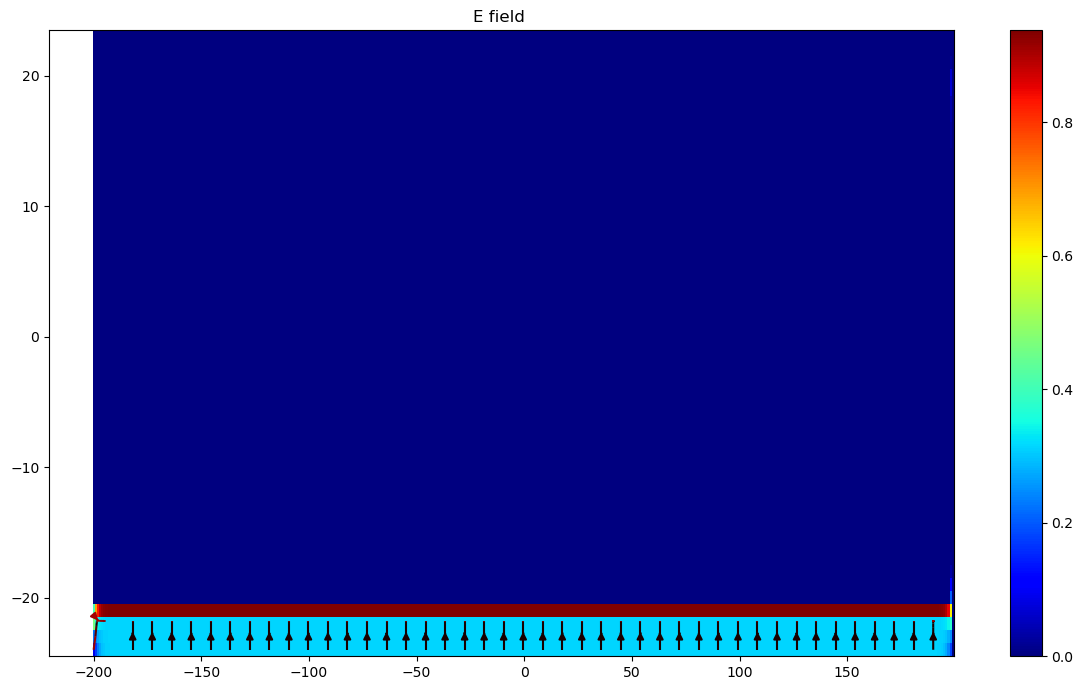

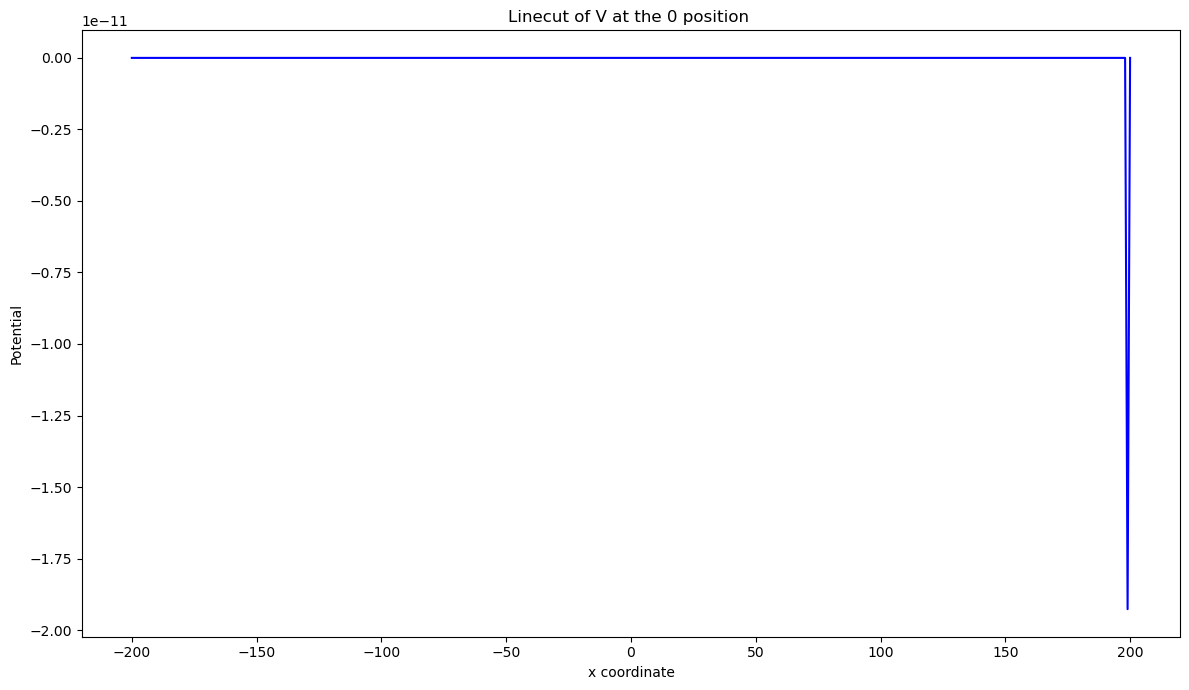

using Dirchlet and realistic size takes 64.96055865287781 seconds ---


In [46]:
### General settings for this iteration### 

### Charges### 
rho_top_left=-0.3
rho_bot=-1.25

### Top half as bottom 14 nm ###
hBN_thickness=int(20*units)  # hbn 14 nm 
bot_to_0=hBN_thickness

## Common names ## 
name2='Ju1 $V_{bot}=$'+str(rho_bot)+'_$V_{top}=$'+str(rho_top_left)

top_hBN=18 ## top hBN thickness
extend_electrodes=1

cut_x=int(75*units) ## junction size
name1='units='+str(units)+'_$d_J$='+str(int(2*cut_x/units))+'nm_'

top_to_0=int(top_hBN*units)
if top_to_0%2==0:
    Ny=hBN_thickness+top_to_0+11
else:
    Ny=hBN_thickness+top_to_0+10

bot_plate_y= int(Ny/2.0)-bot_to_0
top_plate_y=int(Ny/2.0)+top_to_0

start_time=time.time()

name3='_$d_{top}$='+str(int(top_to_0/units))+'$d_{bot}$='+str(int(bot_to_0/4))
save_plot_name='dtop'+str(int(top_to_0/units))+'_Vbot'+str(rho_bot)+'_Vtop'+str(rho_top_left)+'_dJ'+str(int(2*cut_x/units))+'nm'
plot_name=name1+name2+name3

data_cap_JJ_Ju1['data'+str(count)]=capacitor_simulation.capacitors_Dirich(Nx,Ny,ds,dsy,rho_top_left,rho_bot,
                bot_plate_y,top_plate_y,bot_epsr,
                top_epsr,plate_start_x,cut_x,eps, 
                plot_names=save_plot_name,save=save,savename=savename,top_size=1,
                bot_size=1, hd=0,save_obj=save,
                mid_split=False,max_iter=1E4)

print("using Dirchlet and realistic size takes %s seconds ---" % (time.time() - start_time))

count=count+1 ## Add the count to keep storing the data 


In [ ]:
capacitors_equipotential(Nx,Ny,ds,dsy,rho_top_left,rho_bot,rho_mid,bot_plate,
               top_plate,bot_epsr,top_epsr,plate_start_x,
               cut_x,conv_error=10E-6,
               BCs=0, plot_names='', save=False,savename='',top_size=1,
               bot_size=1,hd=0,mid=False,mid_split=False,
               rho_top_right=0,
               max_iter=1E4,cut_center=0,save_obj=False,
               ):

## Plot the electric fields

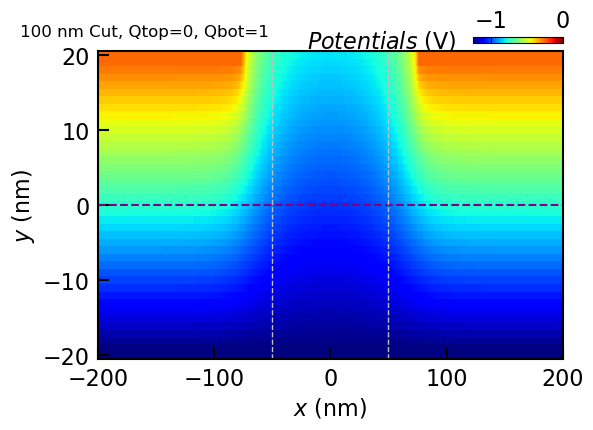

In [24]:
i=0
sty=20
endy=61
stx=0
endx=600
V=data_cap_JJ['data'+str(i)].V[sty:endy,stx:endx]
X_R=data_cap_JJ['data'+str(i)].x_real[sty:endy,stx:endx]
Y_R=data_cap_JJ['data'+str(i)].y_real[sty:endy,stx:endx]
X_ER=data_cap_JJ['data'+str(i)].x_Ereal[sty:endy,stx:endx]
Y_ER=data_cap_JJ['data'+str(i)].y_Ereal[sty:endy,stx:endx]
E_total=data_cap_JJ['data'+str(i)].E_tot[sty:endy,stx:endx]
Ex_c=data_cap_JJ['data'+str(i)].Ex[sty:endy,stx:endx]
Ey_c=data_cap_JJ['data'+str(i)].Ey[sty:endy,stx:endx]

ax,fig=plot_premap(6,4)
im=plt.pcolormesh(X_R,Y_R,V,cmap='jet',vmax=0)
plot_map(ax,im,fig,xlabel='$x$ (nm)',ylabel='$y$ (nm)')
#plt.colorbar()
ax.axhline(y=0,linestyle='dashed',color='purple')
ax.axvline(x=50,linestyle='dashed',linewidth=1,color='silver')
ax.axvline(x=-50,linestyle='dashed',linewidth=1,color='silver')

#ax.streamplot(X_ER,Y_ER,Ex_c,Ey_c,density=1.5,color=Ey_c,cmap='hot_r',linewidth=1)
ax.set_xlim(-200,200)
ax.set_title('100 nm Cut, Qtop=0, Qbot=1',x=0.1,y=1.02,)
ax.text(-20,21,'$Potentials$ (V)',fontsize=font)
plt.show()

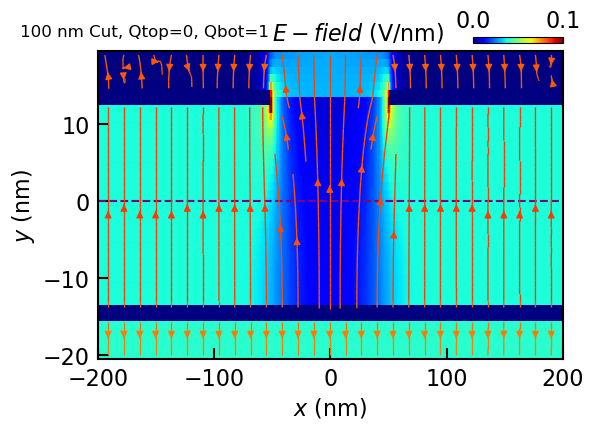

In [311]:
i=4
sty=20
endy=60
stx=0
endx=600
V=data_cap_JJ['data'+str(i)].V[sty:endy,stx:endx]
X_R=data_cap_JJ['data'+str(i)].x_real[sty:endy,stx:endx]
Y_R=data_cap_JJ['data'+str(i)].y_real[sty:endy,stx:endx]
X_ER=data_cap_JJ['data'+str(i)].x_Ereal[sty:endy,stx:endx]
Y_ER=data_cap_JJ['data'+str(i)].y_Ereal[sty:endy,stx:endx]
E_total=data_cap_JJ['data'+str(i)].E_tot[sty:endy,stx:endx]
Ex_c=data_cap_JJ['data'+str(i)].Ex[sty:endy,stx:endx]
Ey_c=data_cap_JJ['data'+str(i)].Ey[sty:endy,stx:endx]

ax,fig=plot_premap(6,4)
im=plt.pcolormesh(X_ER,Y_ER,E_total,cmap='jet',vmax=0.1)
plot_map(ax,im,fig,xlabel='$x$ (nm)',ylabel='$y$ (nm)')
#plt.colorbar()
ax.plot(X_ER[0],X_ER[0]*0,linestyle='dashed',color='purple')
ax.streamplot(X_ER,Y_ER,Ex_c,Ey_c,density=1.5,color=Ey_c,cmap='hot_r',linewidth=1)
ax.set_xlim(-200,200)
ax.set_title('100 nm Cut, Qtop=0, Qbot=1',x=0.1,y=1.02,)
ax.text(-50,21,'$E-field$ (V/nm)',fontsize=font)
plt.show()

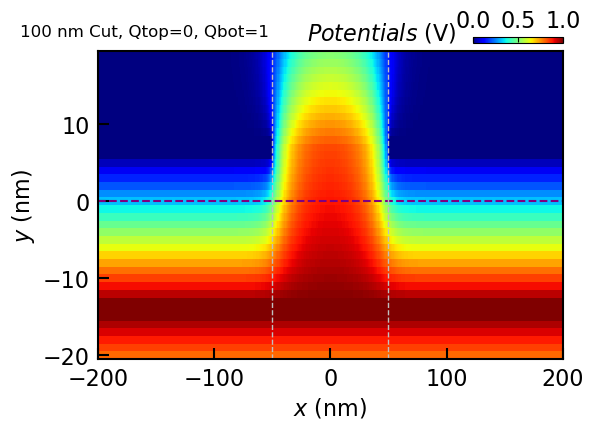

In [362]:
i=3
sty=20
endy=60
stx=0
endx=600
V=data_cap_JJ['data'+str(i)].V[sty:endy,stx:endx]
X_R=data_cap_JJ['data'+str(i)].x_real[sty:endy,stx:endx]
Y_R=data_cap_JJ['data'+str(i)].y_real[sty:endy,stx:endx]
X_ER=data_cap_JJ['data'+str(i)].x_Ereal[sty:endy,stx:endx]
Y_ER=data_cap_JJ['data'+str(i)].y_Ereal[sty:endy,stx:endx]
E_total=data_cap_JJ['data'+str(i)].E_tot[sty:endy,stx:endx]
Ex_c=data_cap_JJ['data'+str(i)].Ex[sty:endy,stx:endx]
Ey_c=data_cap_JJ['data'+str(i)].Ey[sty:endy,stx:endx]

ax,fig=plot_premap(6,4)
im=plt.pcolormesh(X_R,Y_R,V,cmap='jet',vmax=1)
plot_map(ax,im,fig,xlabel='$x$ (nm)',ylabel='$y$ (nm)')
#plt.colorbar()
ax.axhline(y=0,linestyle='dashed',color='purple')
ax.axvline(x=50,linestyle='dashed',linewidth=1,color='silver')
ax.axvline(x=-50,linestyle='dashed',linewidth=1,color='silver')

#ax.streamplot(X_ER,Y_ER,Ex_c,Ey_c,density=1.5,color=Ey_c,cmap='hot_r',linewidth=1)
ax.set_xlim(-200,200)
ax.set_title('100 nm Cut, Qtop=0, Qbot=1',x=0.1,y=1.02,)
ax.text(-20,21,'$Potentials$ (V)',fontsize=font)
plt.show()

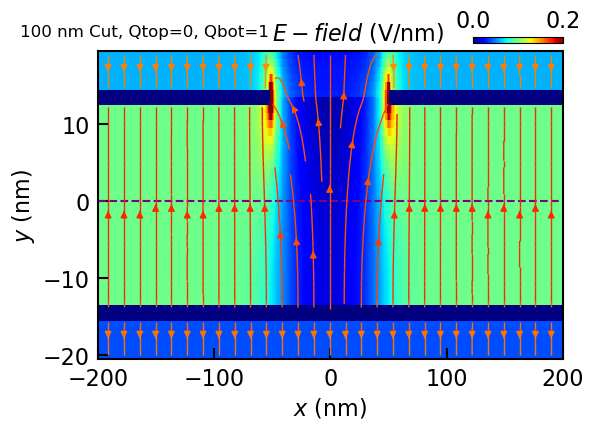

In [355]:
i=28
sty=20
endy=60
stx=0
endx=600
V=data_cap_JJ['data'+str(i)].V[sty:endy,stx:endx]
X_R=data_cap_JJ['data'+str(i)].x_real[sty:endy,stx:endx]
Y_R=data_cap_JJ['data'+str(i)].y_real[sty:endy,stx:endx]
X_ER=data_cap_JJ['data'+str(i)].x_Ereal[sty:endy,stx:endx]
Y_ER=data_cap_JJ['data'+str(i)].y_Ereal[sty:endy,stx:endx]
E_total=data_cap_JJ['data'+str(i)].E_tot[sty:endy,stx:endx]
Ex_c=data_cap_JJ['data'+str(i)].Ex[sty:endy,stx:endx]
Ey_c=data_cap_JJ['data'+str(i)].Ey[sty:endy,stx:endx]

ax,fig=plot_premap(6,4)
im=plt.pcolormesh(X_ER,Y_ER,E_total,cmap='jet',vmax=0.2)
plot_map(ax,im,fig,xlabel='$x$ (nm)',ylabel='$y$ (nm)')
#plt.colorbar()
ax.plot(X_ER[0],X_ER[0]*0,linestyle='dashed',color='purple')
ax.streamplot(X_ER,Y_ER,Ex_c,Ey_c,density=1.5,color=Ey_c,cmap='hot_r',linewidth=1)
ax.set_xlim(-200,200)
ax.set_title('100 nm Cut, Qtop=0, Qbot=1',x=0.1,y=1.02,)
ax.text(-50,21,'$E-field$ (V/nm)',fontsize=font)
plt.show()

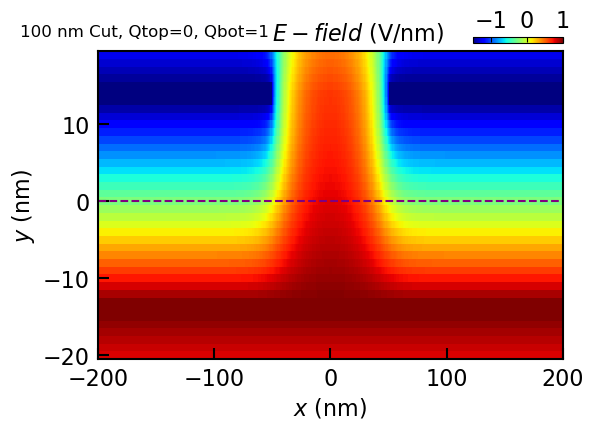

In [360]:
i=28
sty=20
endy=60
stx=0
endx=600
V=data_cap_JJ['data'+str(i)].V[sty:endy,stx:endx]
X_R=data_cap_JJ['data'+str(i)].x_real[sty:endy,stx:endx]
Y_R=data_cap_JJ['data'+str(i)].y_real[sty:endy,stx:endx]
X_ER=data_cap_JJ['data'+str(i)].x_Ereal[sty:endy,stx:endx]
Y_ER=data_cap_JJ['data'+str(i)].y_Ereal[sty:endy,stx:endx]
E_total=data_cap_JJ['data'+str(i)].E_tot[sty:endy,stx:endx]
Ex_c=data_cap_JJ['data'+str(i)].Ex[sty:endy,stx:endx]
Ey_c=data_cap_JJ['data'+str(i)].Ey[sty:endy,stx:endx]

ax,fig=plot_premap(6,4)
im=plt.pcolormesh(X_R,Y_R,V,cmap='jet')
plot_map(ax,im,fig,xlabel='$x$ (nm)',ylabel='$y$ (nm)')
#plt.colorbar()
ax.plot(X_ER[0],X_ER[0]*0,linestyle='dashed',color='purple')
#ax.streamplot(X_ER,Y_ER,Ex_c,Ey_c,density=1.5,color=Ey_c,cmap='hot_r',linewidth=1)
ax.set_xlim(-200,200)
ax.set_title('100 nm Cut, Qtop=0, Qbot=1',x=0.1,y=1.02,)
ax.text(-50,21,'$E-field$ (V/nm)',fontsize=font)
plt.show()

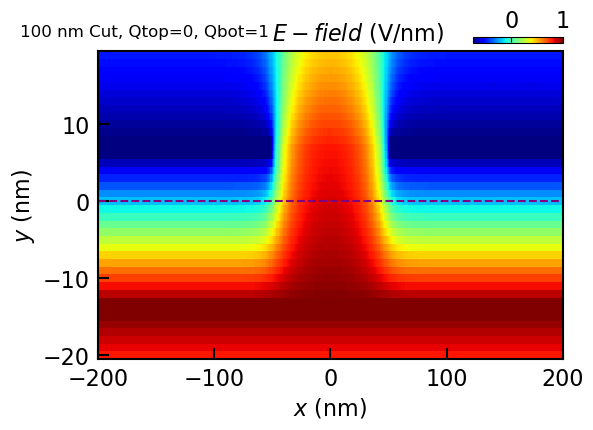

In [364]:
i=27
sty=20
endy=60
stx=0
endx=600
V=data_cap_JJ['data'+str(i)].V[sty:endy,stx:endx]
X_R=data_cap_JJ['data'+str(i)].x_real[sty:endy,stx:endx]
Y_R=data_cap_JJ['data'+str(i)].y_real[sty:endy,stx:endx]
X_ER=data_cap_JJ['data'+str(i)].x_Ereal[sty:endy,stx:endx]
Y_ER=data_cap_JJ['data'+str(i)].y_Ereal[sty:endy,stx:endx]
E_total=data_cap_JJ['data'+str(i)].E_tot[sty:endy,stx:endx]
Ex_c=data_cap_JJ['data'+str(i)].Ex[sty:endy,stx:endx]
Ey_c=data_cap_JJ['data'+str(i)].Ey[sty:endy,stx:endx]

ax,fig=plot_premap(6,4)
im=plt.pcolormesh(X_R,Y_R,V,cmap='jet')
plot_map(ax,im,fig,xlabel='$x$ (nm)',ylabel='$y$ (nm)')
#plt.colorbar()
ax.plot(X_ER[0],X_ER[0]*0,linestyle='dashed',color='purple')
#ax.streamplot(X_ER,Y_ER,Ex_c,Ey_c,density=1.5,color=Ey_c,cmap='hot_r',linewidth=1)
ax.set_xlim(-200,200)
ax.set_title('100 nm Cut, Qtop=0, Qbot=1',x=0.1,y=1.02,)
ax.text(-50,21,'$E-field$ (V/nm)',fontsize=font)
plt.show()